# Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

import gym
from gym import spaces, Env
from gym.spaces import Box, Discrete
import matplotlib.pyplot as plt

from sac_networks import Actor, Critic, ValueNetwork, SACAgent, rescale_action, rescale_array
from collections import deque
from expt_utils import get_latest_folder

from buffer import ReplayBuffer, HERReplayBuffer
import threading
import time
import os

In [ ]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output

from Manipulation_env  import Manipulation_multi_object as Manipulation
#from buffer_functions import save_buffer, load_buffer, append_buffer
from model_buffer_saving_functions import save_replay_buffer, load_replay_buffer, save_sac_agent, load_sac_agent, save_dict_to_h5, load_h5_to_dict
from get_target import custom_target, clear_region, clear_region_levels, sort_target_to_center, y_inv, hexagon_ring_points

In [3]:
import time
import threading
import sys, time, os, threading
from PyQt5 import QtCore, QtWidgets, QtGui
from PyQt5.QtCore import Qt
import random
import string

# Functions


In [ ]:
def initialize_env_agent(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions = 1,continue_to_complete = False, drift_comp = True, reward_tolerance = 0.15,
                         margin = 0, label_margin = 0, target_control = None, nearest_coords_dim =6, st_offset = None, end_offset = None, use_env_reward_fn = True, detect_dict = {},
                         param_model_path = None, offset_model_path = None, replay_buffer_path = None, her_buffer_path = None):
    
    """ Initialize the Manipulation environment, SAC agents for parameter and position control, and replay buffers."""

    
    env = Manipulation(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions = n_transitions, continue_to_complete = continue_to_complete, 
                   drift_comp = drift_comp, reward_tolerance= reward_tolerance, anchor = (False, 0, False), margin = margin, label_margin = label_margin, target_control = target_control, 
                   st_offset = st_offset, end_offset = end_offset, detect_dict = detect_dict)

    state_dim = env.observation_space.shape[0]
    param_action_dim = env.action_space["param"].shape[0]
    position_action_dim = env.action_space["offset"].shape[0]
    goal_dim = env.target.shape[1]
    
    param_agent = SACAgent(state_dim, param_action_dim, gcrl = False, a_lr = 1e-4, c_lr = 3e-4, tau =0.005, goal_dim=0)
    position_agent = SACAgent(state_dim + nearest_coords_dim, position_action_dim, gamma=0.8, gcrl = True, a_lr = 1e-4, c_lr = 3e-4, tau =0.005, goal_dim=goal_dim)

    buffer = ReplayBuffer()
    her_buffer = HERReplayBuffer(k_future=int(0.4*n_transitions), env = env, use_env_reward_fn=use_env_reward_fn) 
    
    if replay_buffer_path is not None:
        buffer.buffer = load_replay_buffer(filename=replay_buffer_path)
    if her_buffer_path is not None:
        her_buffer.buffer = load_replay_buffer(filename=her_buffer_path)

    buffer_dict = {'replay_buffer': buffer, 'her_buffer': her_buffer}

    if param_model_path is not None:
        param_agent = load_sac_agent(param_agent, filename=param_model_path)
    if offset_model_path is not None:
        position_agent = load_sac_agent(position_agent, filename=offset_model_path)
    agent_dict = {'param_agent': param_agent, 'offset_agent': position_agent}
    

    return env, agent_dict, buffer_dict

In [ ]:

def train_model(env, agent_dict, buffer_dict, n_episodes, transitions_per_episode, batch_size, train_start = 256, updates_per_step = 1,
                epsilon = 0.0, recency_factor = 1, stop_event = None, result_container = None, 
                info_callback=None, expt_log_dir = 'model2', get_func_attrs = None):
    
    """ Train the SAC agents in the Manipulation environment using the provided buffers."""
    
    param_agent = agent_dict['param_agent']
    position_agent = agent_dict['offset_agent']

    buffer = buffer_dict['replay_buffer']
    her_buffer = buffer_dict['her_buffer']


    episode_data = {'ep_rewards': [], 'ep_length': []}
    param_training_data = {'actor_loss': [], 'critic_loss': [], 'td_error':[]}
    position_training_data = {'actor_loss': [], 'critic_loss': [], 'td_error':[]}
   
    combine_training_data = lambda d1, d2: {'param': d1, 'offset': d2}
    
    iter_rewards = []


    


    for ep in range(n_episodes):

        obs = env.reset()[0]
        state = obs['observation']
        achieved = obs['achieved_goal']
        goal = obs['desired_goal']   
        state1 = obs['state_with_near_coords'] # state with 3 nearest-neighbor coords


        episode_reward = 0
        
        episode_transitions = []


        for t in range(transitions_per_episode):

            # Update training hyperparameters         
            func_attrs, env, updates_per_step, epsilon, recency_factor, batch_size = update_training_hyperparams(get_func_attrs, env, updates_per_step, epsilon, recency_factor, batch_size)
            


            if stop_event is not None and stop_event.is_set():
                
                print("Training stopped.")
                if result_container is not None:
                    result_container['training_data'] = combine_training_data(param_training_data, position_training_data)
                    result_container['iter_rewards'] = iter_rewards
                return 
            
            if env._finished:
                print("Target reached, Ending training.")
                if result_container is not None:
                    result_container['training_data'] = combine_training_data(param_training_data, position_training_data)
                    result_container['iter_rewards'] = iter_rewards
                return
            
        
            state_initial = state
            with torch.no_grad():
                param_action = param_agent.select_action(state)
                position_action = position_agent.select_action(state1, epsilon = epsilon, goal = goal)


            print(f"Param action: {param_action}, Position action: {position_action}")

            action_dict = {'param': np.ravel(param_action),
                           'offset': np.ravel(position_action)}
            
            next_obs, reward, done, truncation, info = env.step(action_dict)
            next_state = next_obs['observation']
            achieved = next_obs['achieved_goal']
            goal = next_obs['desired_goal']
            next_state1 = next_obs['state_with_near_coords']
            reward_next_state, _ = env._compute_reward(gcrl_reward = True, achieved_goal = achieved, goal = goal) # this is to compute the object-dep reward for the replay_buffer. 
            iter_rewards.append(reward)  # this reward is the summation over all the objects.


            # Indicate the modifed offset as the position_action
            modified_offset = info.get("modified_offset")
            if modified_offset is not None:
                position_action = modified_offset
            
            if info_callback is not None:
                info_callback(info, func_attrs)
            if result_container is not None:
                result_container['iter_rewards'] = iter_rewards

            
            buffer.push(state, param_action, reward_next_state, next_state, done)

            # Store transition for HER buffer - uses the state with nearest neighbor coords
            transition = (state1, position_action, reward, next_state1, goal, achieved, done)
            episode_transitions.append(transition)


            state = next_state
            state1 = next_state1
            episode_reward += reward

            # Traning in on-policy mode. This can be updated at every step or after every episode.
            if len(buffer) > train_start:
                for _ in range(updates_per_step):
                    print("Updating models...")
                    param_training_log = param_agent.update_cql(buffer, batch_size, recency_factor = recency_factor)
                    position_training_log = position_agent.update_cql(her_buffer, 2*batch_size, recency_factor = recency_factor)

                    
                    param_training_data['actor_loss'].append(param_training_log['actor_loss'])
                    param_training_data['critic_loss'].append(param_training_log['critic_loss'])
                    param_training_data['td_error'].append(param_training_log['td_error'])

                    
                    position_training_data['actor_loss'].append(position_training_log['actor_loss'])
                    position_training_data['critic_loss'].append(position_training_log['critic_loss'])
                    position_training_data['td_error'].append(position_training_log['td_error'])

                    
                training_data = combine_training_data(param_training_data, position_training_data) 
                if result_container is not None:
                    result_container['training_data'] = training_data


            if done: # Early termination of the episode if target reached.
                break


        episode_data['ep_rewards'].append(episode_reward)
        episode_data['ep_length'].append(t+1)



        # Add episode transitions to HER buffer
        her_buffer.store_episode(episode_transitions, env = env)
        buffer_dict = {'replay_buffer': buffer, 'her_buffer': her_buffer}
        if result_container is not None:
            result_container['buffer'] = buffer_dict


        # Save buffers and update models
        
        save_replay_buffer(buffer.buffer, filename=os.path.join("buffers\global_buffers", 'global_replay_buffer.h5'))
        save_replay_buffer(her_buffer.buffer, filename=os.path.join("buffers\global_buffers", 'global_her_buffer.h5'))
        save_sac_agent(param_agent, filename=os.path.join(expt_log_dir, 'param_agent.pth'))
        save_sac_agent(position_agent, filename= os.path.join(expt_log_dir, 'offset_agent.pth'))    
                
        training_data = combine_training_data(param_training_data, position_training_data)
        if result_container is not None:
            result_container['training_data'] = training_data
        save_dict_to_h5(training_data, filename= os.path.join(expt_log_dir, 'training_data.h5'))

        
        # Store training data

        if len(buffer) > train_start:

            if ep % 1 == 0:
                print(f"Episode {ep}, Average Reward: {episode_reward:.2f}, Actor Loss: {position_training_log['actor_loss']:.4f}, Critic Loss: {position_training_log['critic_loss']:.4f}")
                print(f"State: {state_initial}, Action: {action_dict}, Next State: {next_state}, Reward: {reward}, Done: {done}")
                

    
    return training_data, buffer_dict, agent_dict, episode_transitions



def info_callback(self, info, func_attrs= None):
    result = info.get('results', None)
    prev_result = info.get('prev_results', None)
    current_iter_results = info.get('current_iter_results', None)
    
    current_iteration = current_iter_results.get('iteration', None) if current_iter_results else None

    print("Current Iteration:", current_iteration )


def update_training_hyperparams(get_func_attrs, env, updates_per_step, epsilon, recency_factor, batch_size):
    func_attrs = None
    if get_func_attrs is not None:
        func_attrs = get_func_attrs()
        updates_per_step = func_attrs.get('updates_per_step', updates_per_step) if func_attrs is not None else updates_per_step
        epsilon = func_attrs.get('epsilon', epsilon) if func_attrs is not None else epsilon
        recency_factor = func_attrs.get('recency_factor', recency_factor) if func_attrs is not None else recency_factor
        batch_size = func_attrs.get('batch_size', batch_size) if func_attrs is not None else batch_size
        func_attrs = {"updates_per_step": updates_per_step, "epsilon": epsilon, "recency_factor":recency_factor, "batch_size":batch_size}


        # Modify the env-params
        detect_dict = func_attrs.get('detect_dict', {}) if func_attrs is not None else {}
        target_n = detect_dict.get('target_n', None)
        if target_n is not None and target_n > 0:  # indicate target number of molecules
            env.detect_dict['target_n'] = int(target_n)
        
        use_prev = detect_dict.get('use_prev', None) # use prev labels in the detection loss function.
        if use_prev is not None:
            env.detect_dict['use_prev'] = bool(use_prev)
        
        #for transmitting the func_attrs
        detect_dict = {'target_n': env.detect_dict.get('target_n', None), 'use_prev': env.detect_dict.get('use_prev', None)}
        func_attrs = {"updates_per_step": updates_per_step, "epsilon": epsilon, "recency_factor": recency_factor, "batch_size": batch_size, "detect_dict": detect_dict}
  
    return func_attrs, env, updates_per_step, epsilon, recency_factor, batch_size


In [6]:
def save_settings(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_episodes, 
         n_transitions, continue_to_complete, drift_comp, batch_size, train_start, updates_per_step, epsilon, 
        recency_factor, reward_tolerance, margin, label_margin, detect_dict,
         target_control, st_offset, end_offset, use_env_reward_fn, param_model_path, 
         offset_model_path, replay_buffer_path, her_buffer_path, expt_log_dir, notes):
  settings = {
    'param_range': param_range.tolist(),
    'default_action_params': default_action_params.tolist(),
    'expt_name': expt_name,
    'sxm_basename': sxm_basename,
    'expt_dir': expt_dir,
    'n_episodes': n_episodes,
    'n_transitions': n_transitions,
    'continue_to_complete': continue_to_complete,
    'drift_comp': drift_comp,
    'batch_size': batch_size,
    'train_start': train_start,
    'updates_per_step': updates_per_step,
    'epsilon':epsilon,
    'recency_factor':recency_factor,
    'reward_tolerance': reward_tolerance,
    'margin':margin,
    'label_margin':label_margin,
    'detect_dict': detect_dict,
    'target_control': target_control,
    'st_offset': st_offset,
    'end_offset': end_offset,
    'use_env_reward_fn': use_env_reward_fn,
    'param_model_path': param_model_path,
    'offset_model_path': offset_model_path,
    'replay_buffer_path': replay_buffer_path,
    'her_buffer_path': her_buffer_path,
    'notes': notes
  }
  if not os.path.exists(expt_log_dir):
      os.makedirs(expt_log_dir)
  settings_path = os.path.join(expt_log_dir, 'settings.txt')
  with open(settings_path, 'w') as f:
    for key, value in settings.items():
      f.write(f"{key}: {value}\n")
  print(f"Settings saved to {settings_path}")

# Training

In [7]:
# ip_target = custom_target('targets/graphitic_6a_15nm.txt') #target_7a_frame10
# #ip_target = clear_region_levels(40, margin = 0.12)
# ip_target = sort_target_to_center(ip_target, to_center = True)
# print(ip_target.shape)

#ip_target = custom_target('graphitic_6a_15nm.txt') #target_7a_frame10
ip_target = hexagon_ring_points(rings = 3, a = 6*0.23, center = [0.50, 0.50], frame_size = 15, decimal_roundup = 4)
#ip_target = clear_region_levels(30, margin = 0.1)
print(ip_target.shape)

ip_target = sort_target_to_center(ip_target, to_center = True, center_coord = [0.50, 0.50])  #[0:7, :]

# ip_target = np.delete(ip_target, 0, axis = 0)

#order = [0, 1, 3, 2, 6, 4, 5]
#ip_target = np.asarray([ip_target[i] for i in order])
correction_factor =np.asarray([1.03, 0.988]) # np.asarray([1.03, 0.985])

ip_target = (np.asarray(ip_target) - np.asarray([0.5, 0.5]))*correction_factor + np.asarray([0.5, 0.5])
print(ip_target.shape)



(37, 2)
(37, 2)


In [8]:
bias_range = [0.010, 0.030]   # (V)
setpoint_range = [80, 90]   # (nA)
speed_range = [0.5, 2]     #(nm/s)

#Default parameters (V, nA, nm/s):
bias = 0.150
setpoint = 1
speed = 2

expt_name = 'RL129_3ring_4a_online_'

sxm_basename = 'CO_on_Cu_'

expt_dir = r"E:\Ganesh\Manipulation_expts\routine10"

expt_log_dir = os.path.join(expt_dir, 'expt_log', expt_name)

n_episodes =  2000
n_transitions = 10
drift_comp = False
batch_size = 256
train_start = 1024
updates_per_step = 1
continue_to_complete = True
epsilon = 0.1
margin = 0.05
label_margin = 0.01
recency_factor =1

reward_tolerance = 0.165 # in nm.

target_control =   {
                    "target_type": "user_input",
                    "target_coords":np.asarray(ip_target),
                    "anchor":{"condition": True, "anchor_idx":0}, 
                     "drift_comp": "trigger_on_anchor" 
                    }



st_offset = {"type": "start_offset", "delta_offset":0.001}
end_offset = None
#end_offset = {"type": "custom_target_offset", "offset": np.array([0, 0])} # to avoid offsets
detect_dict = {"target_n":39, "use_prev":False}



param_range = np.array([bias_range, setpoint_range, speed_range])
default_action_params = np.array([bias, setpoint, speed])
use_env_reward_fn = True  # in her_buffer

param_model_path = r'rl_models\rl_models\param\rescaled2_training22_a_lr1e-4_weight_decay1e-6\sac_agent_cql_10000.pth'
offset_model_path = r'rl_models\rl_models\offset\sac_agent_cql_100000.pth'
replay_buffer_path = r"buffers\global_buffers\global_replay_buffer.h5"
her_buffer_path = r"buffers\global_buffers\global_her_buffer.h5"


update_from_previous = False
latest_folder = get_latest_folder(os.path.join(expt_dir, 'expt_log'))
latest_folder = "RL122_3ring_4a_online_"
if latest_folder is not None and update_from_previous:
    print("Loading models and buffers from latest folder:", latest_folder)
    latest_folder = os.path.join(expt_dir, 'expt_log', latest_folder)
    param_model_path = os.path.join(latest_folder, 'param_agent.pth')
    offset_model_path = os.path.join(latest_folder, 'offset_agent.pth')
    # replay_buffer_path = os.path.join(latest_folder, 'replay_buffer.h5')
    # her_buffer_path = os.path.join(latest_folder, 'her_buffer.h5')

notes = f"new_area\ncorrection_factor:{correction_factor}\n"

#save settings
save_settings(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_episodes, 
       n_transitions, continue_to_complete, drift_comp, batch_size, train_start, updates_per_step, epsilon, recency_factor, reward_tolerance,
        margin, label_margin, detect_dict, target_control, st_offset, end_offset, use_env_reward_fn, param_model_path, 
       offset_model_path, replay_buffer_path, her_buffer_path, expt_log_dir, notes)

training_fn_attrs = {'updates_per_step': updates_per_step, 'epsilon': epsilon, 'recency_factor': recency_factor, "batch_size": batch_size, 
                     'detect_dict':detect_dict}

Settings saved to E:\Ganesh\Manipulation_expts\routine10\expt_log\RL129_3ring_4a_online_\settings.txt


sxm_file_name: CO_on_Cu_1392.sxm


C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


sxm_file_name: CO_on_Cu_1392.sxm


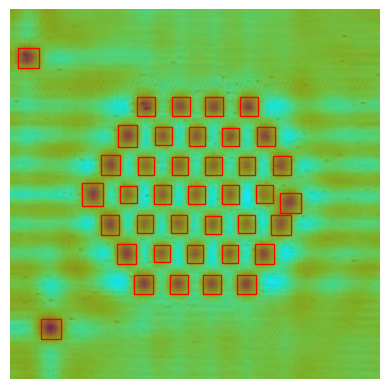

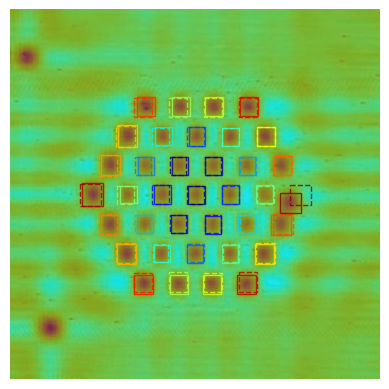

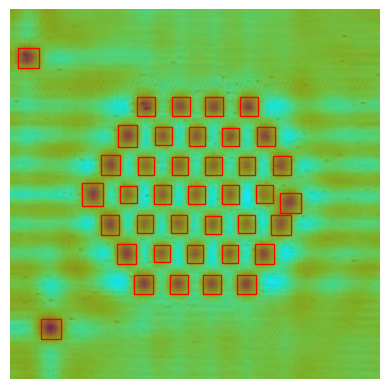

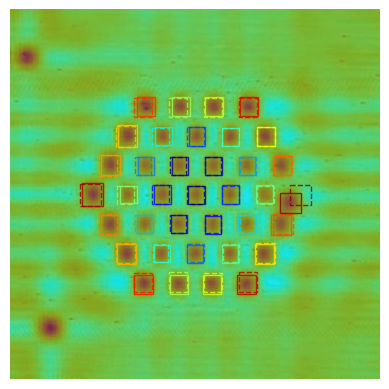

In [9]:
env, agent_dict, buffer_dict = initialize_env_agent(param_range, default_action_params, expt_name, sxm_basename, expt_dir, n_transitions,
                                                    continue_to_complete= continue_to_complete, drift_comp=drift_comp, reward_tolerance=reward_tolerance,
                                                    margin = margin, label_margin = label_margin,
                                                    target_control=target_control, nearest_coords_dim=7, st_offset = st_offset, end_offset=end_offset, use_env_reward_fn = use_env_reward_fn,
                                                    detect_dict = detect_dict, param_model_path=param_model_path, 
                                                    offset_model_path = offset_model_path, replay_buffer_path= replay_buffer_path, her_buffer_path=her_buffer_path)

In [10]:
# print(len(episode_transitions))

In [11]:
# training_data, buffer_dict, agent_dict, episode_transitions = train_model(en-v, agent_dict, buffer_dict , 1, 1, batch_size = 3, train_start = 3)

# Interface


image 1/1 E:\Ganesh\Manipulation_expts\routine10\images\CO_on_Cu_1394.jpg: 256x256 39 COs, 98.6ms
Speed: 0.0ms preprocess, 98.6ms inference, 0.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs\detect\predict1006
1 label saved to runs\detect\predict1006\labels
label path is here: runs\detect\predict1006\labels\CO_on_Cu_1394.txt
Updating models...
Episode 0, Average Reward: 729.60, Actor Loss: 0.5845, Critic Loss: 52.6498
State: [[     0.8222     0.47114     0.78428         0.5     0.39648]], Action: {'param': array([   -0.34918,    -0.42481,    -0.43059], dtype=float32), 'offset': array([    0.75914,    -0.95154], dtype=float32)}, Next State: [[    0.77717     0.49822     0.78428         0.5     0.03899]], Reward: 370, Done: True
All objects are complete.
sxm_file_name: CO_on_Cu_1394.sxm
Target reached, Ending training.


SystemExit: 0

C:\Users\Administrator\AppData\Roaming\Python\Python310\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


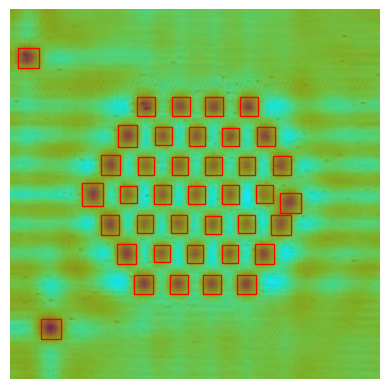

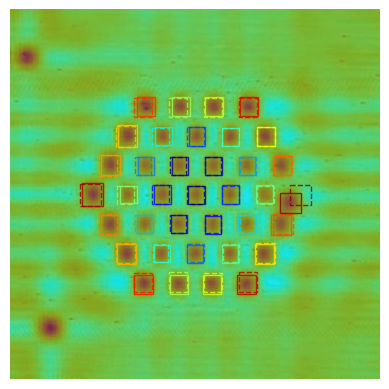

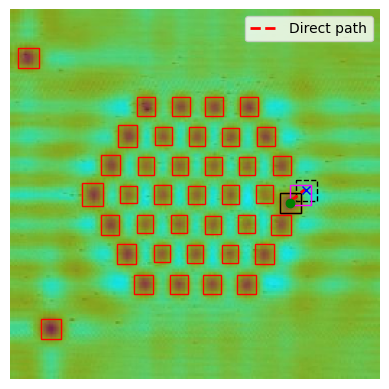

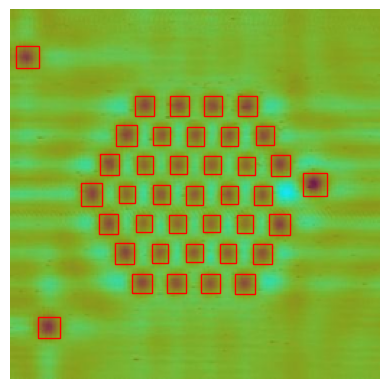

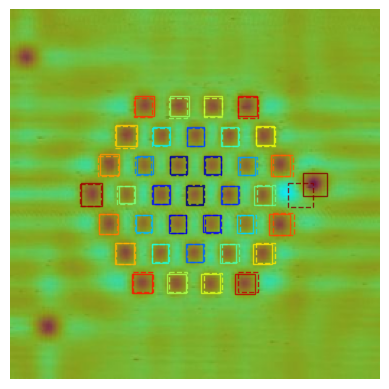

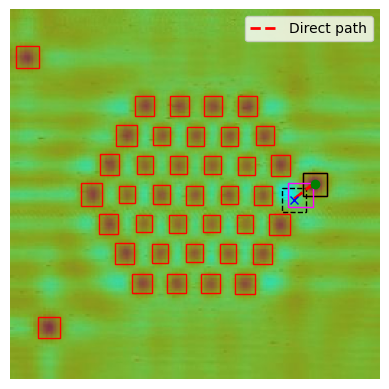

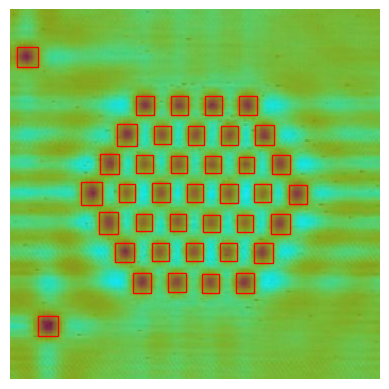

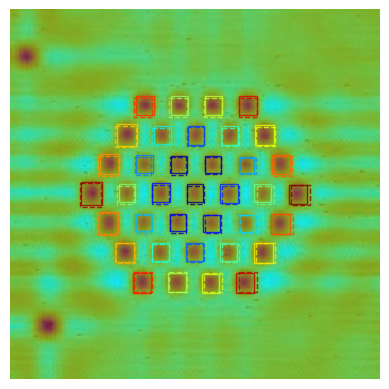

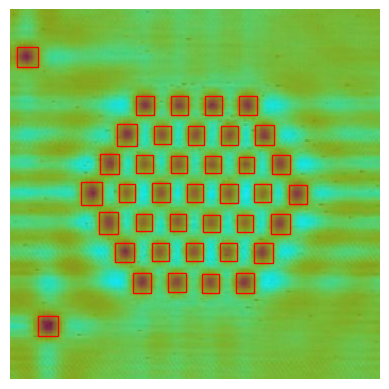

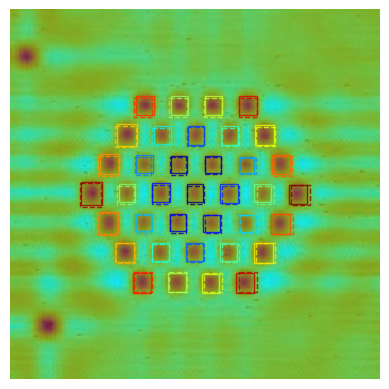

In [12]:
from gui.gui import Manipulation_GUI

def main():
    import sys
    app = QtWidgets.QApplication(sys.argv)
    win = Manipulation_GUI(train_model, env, agent_dict, buffer_dict, n_episodes, n_transitions, batch_size, train_start, updates_per_step, epsilon, training_fn_attrs)
    win.show()
    sys.exit(app.exec_())


if __name__ == "__main__":
    main()